#### 1. Load and Inspect the Data

In [2]:
import pandas as pd

df = pd.read_csv('datasets/customer_churn.csv')
print(df.shape)
df.head()


(900, 10)


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


#### 2. Basic Exploration

In [3]:
df.info()
df['Churn'].value_counts()  # Check class balance


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


Churn
0    750
1    150
Name: count, dtype: int64

#### 2.1. drop the customer name

In [4]:
df = df.drop('Names', axis=1, errors='ignore')
df = df.drop(['Company'], axis=1)  # Company name likely doesn't help
df = df.drop(['Onboard_date'], axis=1)  # Onboard_date
df = df.drop(['Location'], axis=1)  # Location


df

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1
...,...,...,...,...,...,...
895,42.0,12800.82,1,3.62,8.0,0
896,52.0,9893.92,0,6.91,7.0,0
897,45.0,12056.18,0,5.46,4.0,0
898,51.0,6517.93,1,5.47,10.0,0


#### 3.Separate Features and Target

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [6]:
X

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,42.0,11066.80,0,7.22,8.0
1,41.0,11916.22,0,6.50,11.0
2,38.0,12884.75,0,6.67,12.0
3,42.0,8010.76,0,6.71,10.0
4,37.0,9191.58,0,5.56,9.0
...,...,...,...,...,...
895,42.0,12800.82,1,3.62,8.0
896,52.0,9893.92,0,6.91,7.0
897,45.0,12056.18,0,5.46,4.0
898,51.0,6517.93,1,5.47,10.0


In [7]:
y

0      1
1      1
2      1
3      1
4      1
      ..
895    0
896    0
897    0
898    0
899    0
Name: Churn, Length: 900, dtype: int64

#### 4.Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
X_train

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
10,30.0,11575.37,1,5.22,8.0
334,40.0,6773.23,1,4.29,11.0
244,37.0,15070.32,0,6.91,6.0
678,43.0,5907.07,0,5.89,8.0
306,46.0,11538.57,1,7.93,10.0
...,...,...,...,...,...
106,43.0,6715.23,0,4.16,8.0
270,44.0,9613.84,1,4.38,8.0
860,39.0,13731.45,1,8.15,10.0
435,36.0,12879.70,0,4.70,9.0


#### 5.Train Logistic Regression

In [10]:
X_train

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
10,30.0,11575.37,1,5.22,8.0
334,40.0,6773.23,1,4.29,11.0
244,37.0,15070.32,0,6.91,6.0
678,43.0,5907.07,0,5.89,8.0
306,46.0,11538.57,1,7.93,10.0
...,...,...,...,...,...
106,43.0,6715.23,0,4.16,8.0
270,44.0,9613.84,1,4.38,8.0
860,39.0,13731.45,1,8.15,10.0
435,36.0,12879.70,0,4.70,9.0


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


G:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
print(df.columns)


Index(['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites',
       'Churn'],
      dtype='object')


#### 6.Evaluate the Model


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


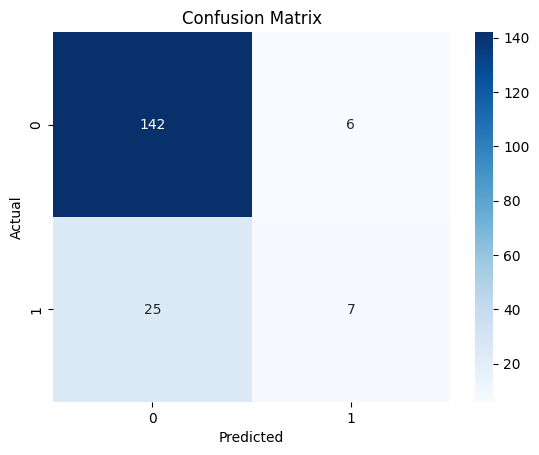

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       148
           1       0.54      0.22      0.31        32

    accuracy                           0.83       180
   macro avg       0.69      0.59      0.61       180
weighted avg       0.79      0.83      0.80       180



In [13]:
!pip install seaborn
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))


#### 7.1add scaling 

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 7.2. Train logistic regression

In [15]:
model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

LogisticRegression(solver='liblinear')

#### 7.3.Predict and evaluate

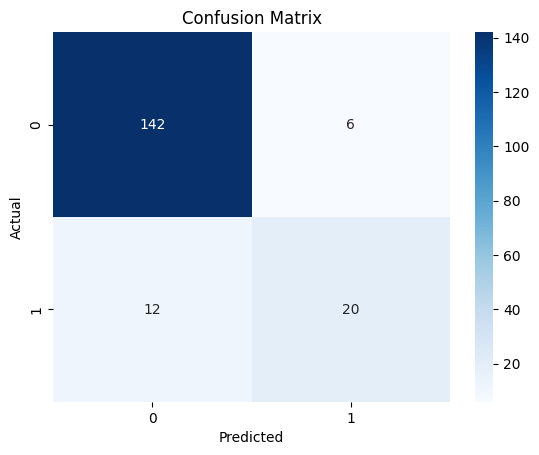


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.77      0.62      0.69        32

    accuracy                           0.90       180
   macro avg       0.85      0.79      0.82       180
weighted avg       0.89      0.90      0.90       180



In [17]:
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("\nClassification Report:\n", report)